# MODELO DE REGRESIÓN LINEAL SIMPLE CON DATASET REAL
## Predicción del precio de una casa

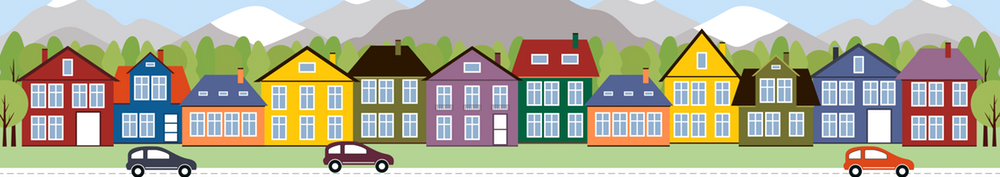

## 1 - IMPORTAMOS LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2 - CARGAMOS DATASET

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data',header=None,sep=r'\s+')
df.columns =  ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## 3 - CORRELACIONES

In [3]:
plt.rcParams['figure.figsize'] = (12, 8)

<Axes: >

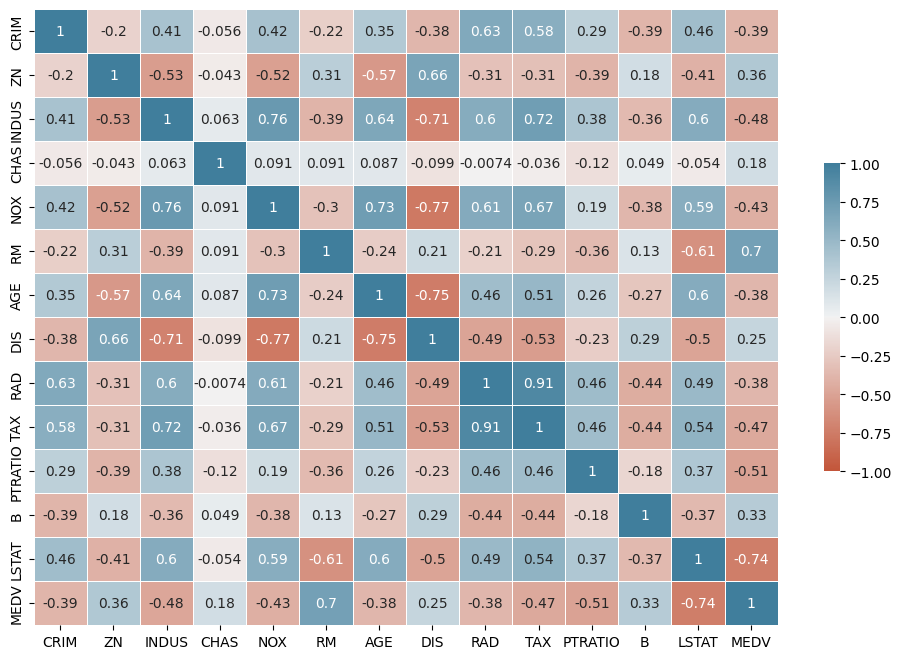

In [4]:
sns.heatmap(
    data=df.corr(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## 4 - ANALIZAMOS LA VARIABLE CON MAYOR CORRELACIÓN(RM - MEDV)

<Axes: xlabel='RM', ylabel='MEDV'>

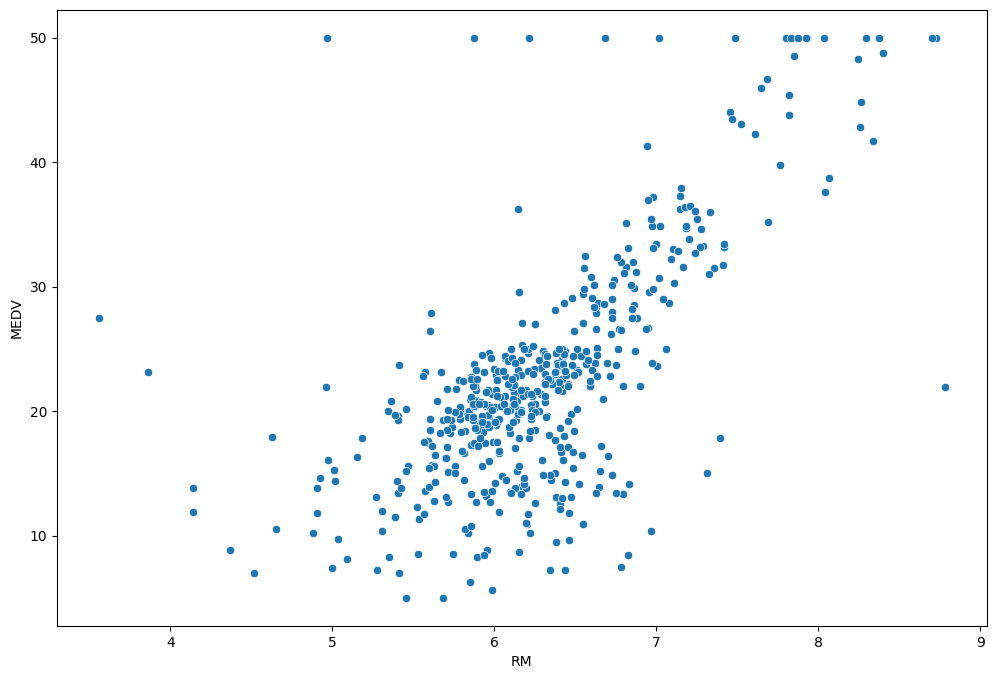

In [5]:
sns.scatterplot(data=df,x=df['RM'],y=df['MEDV'])

## 5 - CREAMOS UN MODELO DE REGRESIÓN LINEAL SIMPLE PARA X = RM Y = MEDV

## 🧮 1. Regresión Lineal Simple

Es el caso más básico donde se relaciona **una sola variable independiente** `X` con la variable dependiente `Y`.

### 📐 Ecuación:

$$
Y = \beta_0 + \beta_1 X + \varepsilon
$$

- \( Y \): variable dependiente  
- \( X \): variable independiente  
- \( \beta_0 \): intercepto o término independiente  
- \( \beta_1 \): pendiente o coeficiente de regresión  
- \( \varepsilon \): término de error (ruido)

---

## 1 - DEFINIR VARIABLE X y Y

* X = RM(PROMEDIO DE HABITACIONES EN EL DEPARTAMENTO)
* Y = MEDV(VALOR PROMEDIO DEL DEPARTAMENTO)

In [6]:
X = df['RM'].values.reshape(-1,1)
y = df['MEDV'].values.reshape(-1,1)

## 2 - IMPORTAR LIBREARIAS DE SKLEARN

In [7]:
from sklearn.linear_model import LinearRegression

## 3 - CREAMOS EL MODELO Y LO ENTRENAMOS CON LA DATA

In [9]:
slr = LinearRegression()
slr.fit(X,y)
y_pred = slr.predict(X)

## 4 - GRAFICAMOS LOS RESULTADOS

Text(0.5, 0, 'RM')

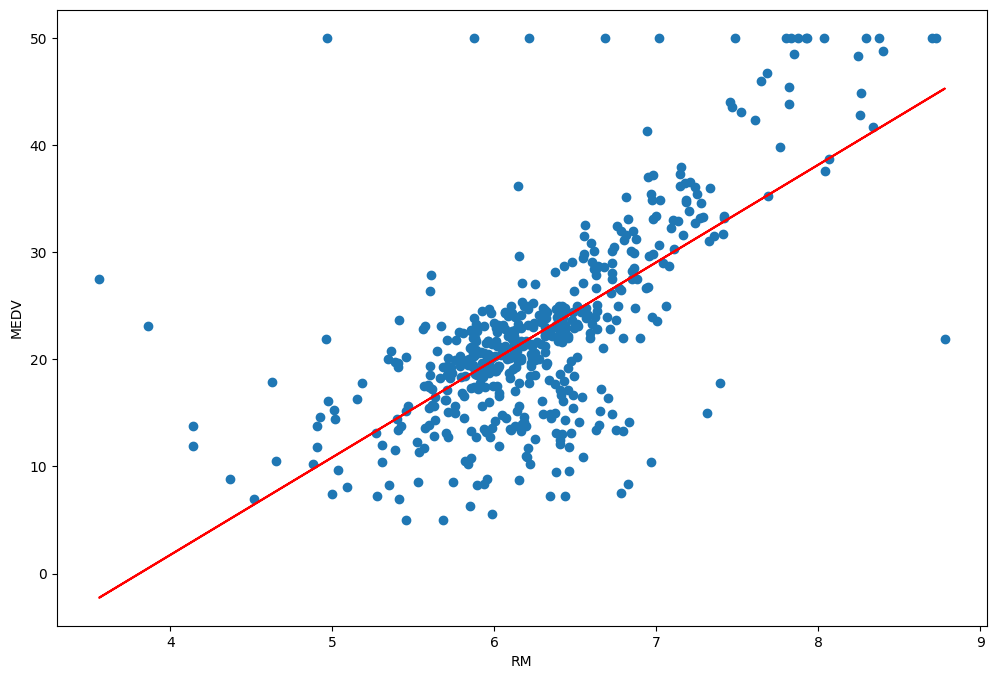

In [10]:
plt.scatter(X,y)
plt.plot(X,y_pred,color='red')
plt.ylabel('MEDV')
plt.xlabel('RM')

## 5 - PROBAMOS CON NUEVA DATA

In [11]:
num_hab = 4
num_hab_arr = np.array(num_hab).reshape(-1,1)
y_pred_hab = slr.predict(num_hab_arr)
print(f" EL PRECIO PARA UN DPTO CON {num_hab}  ES DE : {y_pred_hab}")

 EL PRECIO PARA UN DPTO CON 4  ES DE : [[1.73781515]]
